# Random Forest

This notebook trains an **Random Forest** model to classify chest X‑rays into three classes: **normal**, **bacteria**, **virus**.

## 1. Loading the augmentation pipeline

In this first step, we **reuse** the `on_the_fly_augmentation.ipynb` notebook:

- it downloads the chest X‑ray dataset,
- applies the Albumentations augmentations,
- builds `train_loader`, `val_loader`, and `test_loader` (PyTorch `DataLoader` objects).

This notebook therefore focuses only on the **model + training** part.

C:\Users\vasil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully!

Augmentation pipelines created!

Loading dataset...


C:\Users\vasil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)



  Dataset loaded!
  Train: 4705 images
  Validation: 522 images
  Test: 624 images

 Transforms applied!
 Images will be augmented on-the-fly when you load them


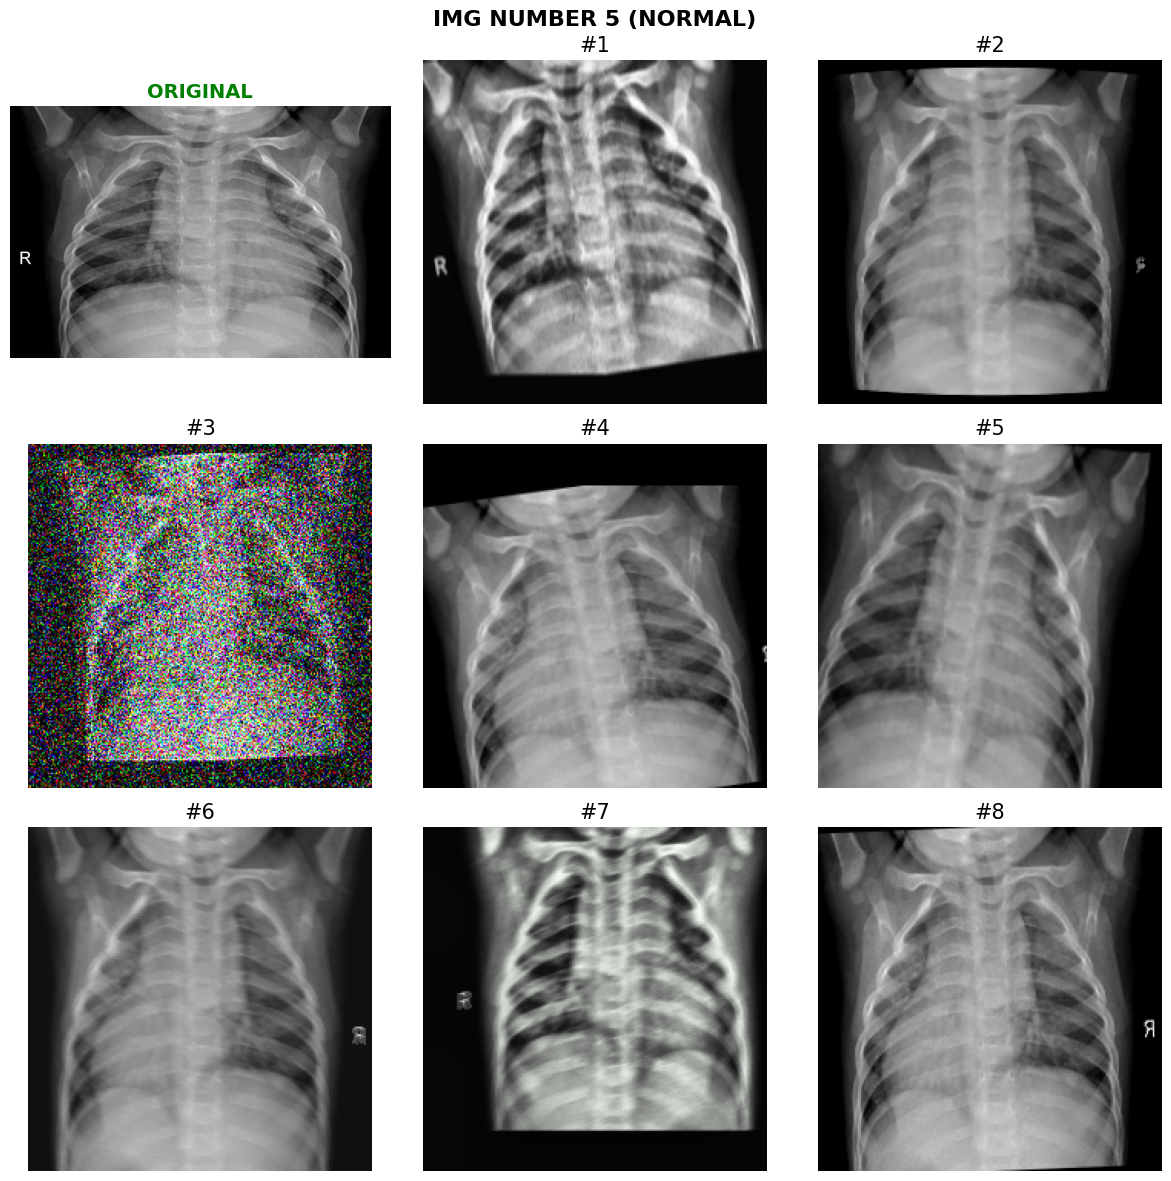


  DataLoaders ready!
  Batch size: 32
  Train batches: 148
  Val batches: 17
  Test batches: 20
Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])

First 10 labels: [1, 2, 1, 1, 1, 1, 1, 0, 2, 0]
Label distribution: [8, 18, 6]


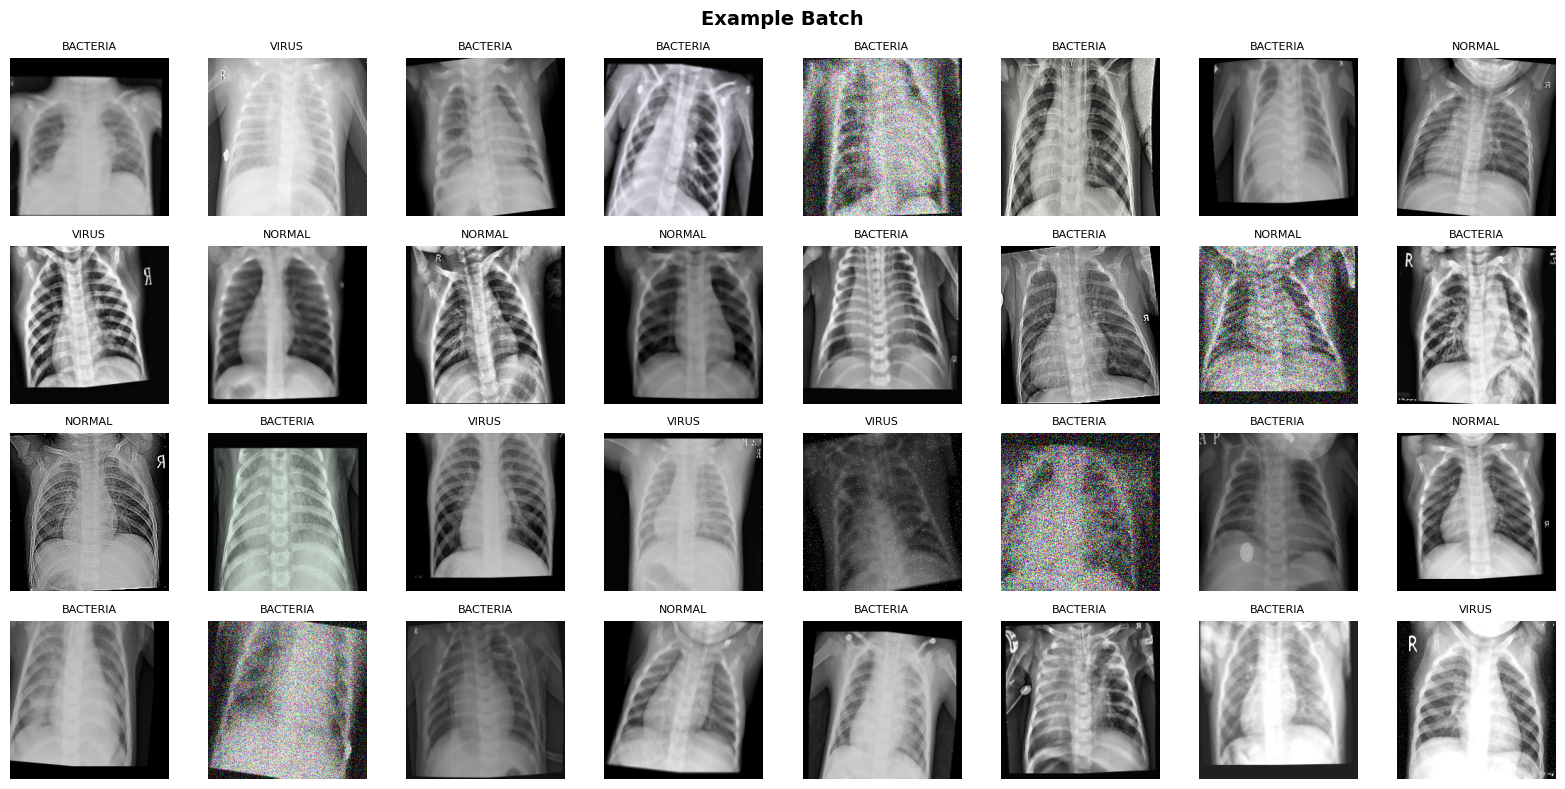

In [2]:
# Run the on-the-fly augmentation notebook
# This defines: dataset, train_data, val_data, test_data,
# as well as train_loader, val_loader, test_loader

%run "../on_the_fly_augmentation.ipynb"

## 2. Defining Random Forest and hyperparameters

- set model **hyperparameters** (number of trees, max depth, random state),
- define **NUM_CLASSES** = 3 (normal, bacteria, virus),
- define a **PCA** transformer to reduce feature dimensionality,
- initialize the **Random Forest** classifier for multiclass classification.

In [8]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import torch

# Model hyperparameters
NUM_CLASSES = 3  # normal, bacteria, virus
N_ESTIMATORS = 500  # number of trees in the forest
MAX_DEPTH = 20  # limit depth to prevent overfitting
RANDOM_STATE = 42
N_COMPONENTS_PCA = 256  # reduced dimensionality after PCA
CLASS_WEIGHT = 'balanced'  # handle class imbalance

# Initialize StandardScaler for feature normalization
scaler = StandardScaler()

# Initialize PCA for feature reduction
pca = PCA(n_components=N_COMPONENTS_PCA, random_state=RANDOM_STATE)

# Initialize SMOTE for class balancing
# smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)

# Initialize Random Forest Classifier with class balancing
rf_model = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    class_weight=CLASS_WEIGHT, 
    verbose=1
)

print(" Random Forest Model Initialized")
print(f"  - NUM_CLASSES: {NUM_CLASSES}")
print(f"  - N_ESTIMATORS: {N_ESTIMATORS}")
print(f"  - MAX_DEPTH: {MAX_DEPTH}")
print(f"  - PCA components: {N_COMPONENTS_PCA}")
print(f"  - Class weight: {CLASS_WEIGHT}")


 Random Forest Model Initialized
  - NUM_CLASSES: 3
  - N_ESTIMATORS: 500
  - MAX_DEPTH: 20
  - PCA components: 256
  - Class weight: balanced


## 3. Extract features and train Random Forest

- **extract image features** from the DataLoaders by converting images to flattened vectors,
- apply **PCA** for dimensionality reduction,
- **fit** the Random Forest model on the training data,
- **evaluate** on validation and test sets,
- compute metrics: **accuracy**, **classification report**, **confusion matrix**.


In [9]:
def extract_features(loader):
    """Extract and flatten image features from a DataLoader"""
    X_parts, y_parts = [], []
    for batch in loader:
        # batch is a dict with 'image' and 'label' keys
        imgs = batch['image']
        labels = batch['label']
        
        imgs = imgs.detach().cpu().numpy() if isinstance(imgs, torch.Tensor) else np.array(imgs)
        labels = labels.detach().cpu().numpy() if isinstance(labels, torch.Tensor) else np.array(labels)
        
        bs = imgs.shape[0]
        X_parts.append(imgs.reshape(bs, -1))
        y_parts.append(labels)
    
    X = np.concatenate(X_parts, axis=0)
    y = np.concatenate(y_parts, axis=0)
    return X, y

print("Extracting features from train set...")
X_train, y_train = extract_features(train_loader)
print(f"  Train features shape: {X_train.shape}")
print(f"  Class distribution: {np.bincount(y_train.astype(int))}")

print("Extracting features from validation set...")
X_val, y_val = extract_features(val_loader)
print(f"  Val features shape: {X_val.shape}")

print("Extracting features from test set...")
X_test, y_test = extract_features(test_loader)
print(f"  Test features shape: {X_test.shape}")

# Apply StandardScaler for feature normalization
print("\nApplying StandardScaler...")
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print(f"  Scaled features shape: {X_train_scaled.shape}")

# Apply PCA for dimensionality reduction
print("\nApplying PCA...")
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)
print(f"  PCA reduced shape: {X_train_pca.shape}")
print(f"  Explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")

# Apply SMOTE to balance training classes
print("\nApplying SMOTE for class balancing...")
X_train_pca_balanced, y_train_balanced = smote.fit_resample(X_train_pca, y_train)
print(f"  Balanced training shape: {X_train_pca_balanced.shape}")
print(f"  Balanced class distribution: {np.bincount(y_train_balanced.astype(int))}")

# Train Random Forest with balanced classes
print("\nTraining Random Forest...")
rf_model.fit(X_train_pca_balanced, y_train_balanced)
print("  Training complete!")

# Evaluate on validation set
y_val_pred = rf_model.predict(X_val_pca)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"\nValidation Accuracy: {val_accuracy:.4f}")

# Evaluate on test set
y_test_pred = rf_model.predict(X_test_pca)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=["NORMAL", "BACTERIA", "VIRUS"]))

print("\nTest Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))


Extracting features from train set...
  Train features shape: (4705, 150528)
  Class distribution: [1175 2362 1168]
Extracting features from validation set...
  Val features shape: (522, 150528)
Extracting features from test set...
  Test features shape: (624, 150528)

Applying StandardScaler...


MemoryError: Unable to allocate 5.28 GiB for an array with shape (4705, 150528) and data type float64